<a href="https://colab.research.google.com/github/Sohan-tough/EthicsAI_Experiments/blob/main/Exp8_EthicsAI_23102A0056.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- STEP 1: DOWNLOADING & LOADING DATASET ---
Using Colab cache for faster access to the 'fake-news-detection-datasets' dataset.
Path to dataset files: /kaggle/input/fake-news-detection-datasets
Dataset loaded successfully. Total samples used: 13469

--- STEP 2: PREPROCESSING & DEBIASING ---
Text cleaning complete.

--- STEP 3: MODEL TRAINING (Q1: PERFORMANCE COMPARISON) ---
Accuracy BEFORE removing identifiable/biased data: 0.9800
Accuracy AFTER removing identifiable/biased data:  0.9733


/tmp/ipykernel_3827/517941934.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Biased Model (Full Data)', 'Debiased Model (Filtered)'], y=[acc_b, acc_d], palette=['#e74c3c', '#2ecc71'])


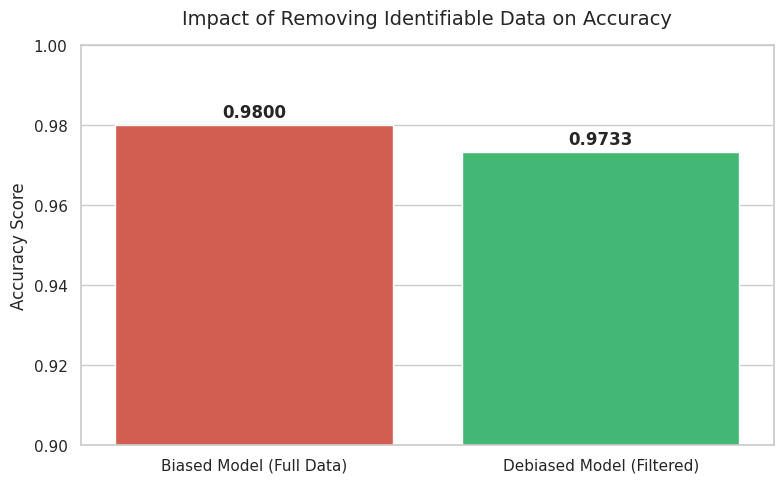


--- STEP 4: BIAS IDENTIFICATION (Q2: MODEL BIAS) ---


/tmp/ipykernel_3827/517941934.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fake_weights, y=top_fake_words, ax=axes[0], palette="Reds_r")
/tmp/ipykernel_3827/517941934.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_true_weights, y=top_true_words, ax=axes[1], palette="Greens_d")


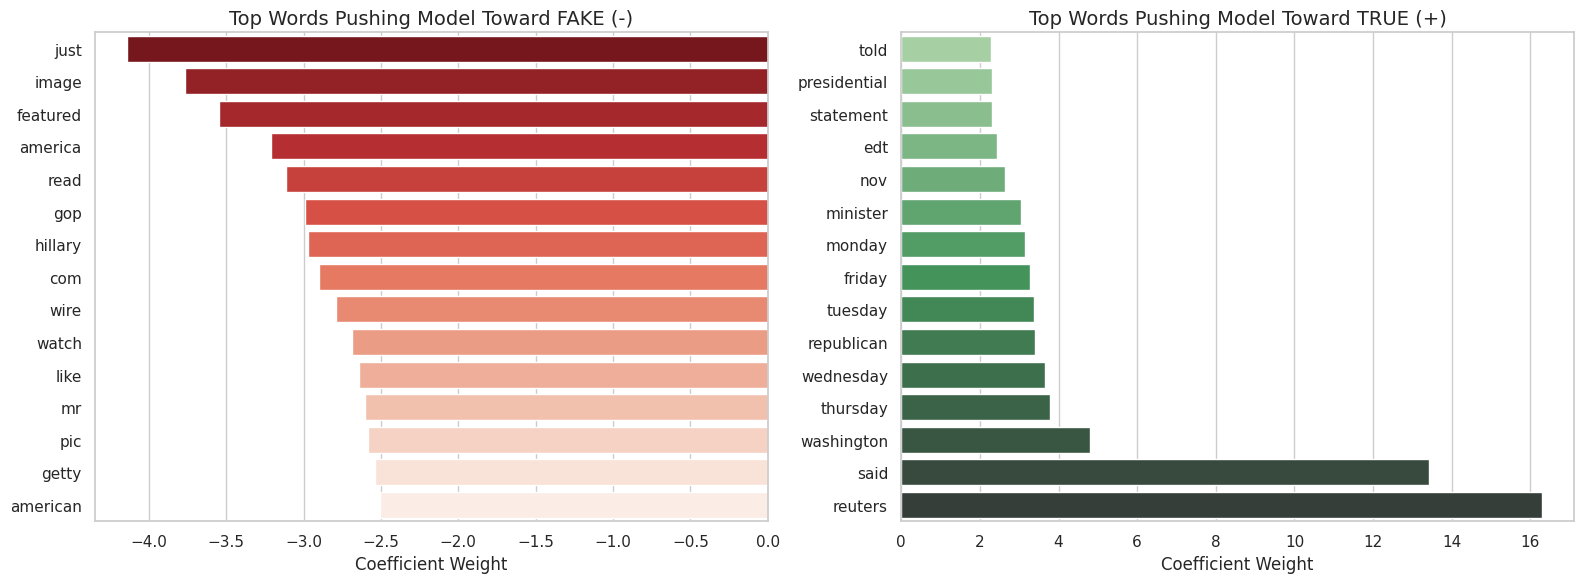


--- STEP 5: EXPLAINABILITY & PUBLIC DEPLOYMENT (Q3 & Q5) ---

Text: 'Washington (Reuters) - The President signed a new executive order today....'
Prediction: TRUE (Confidence: 96.99%)


/tmp/ipykernel_3827/517941934.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights, y=words, palette=colors)


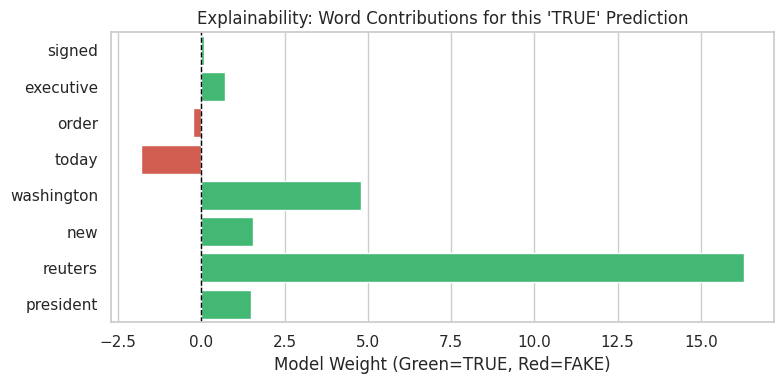

/tmp/ipykernel_3827/517941934.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights, y=words, palette=colors)



Text: 'Breaking: Hillary Clinton caught on video making deals with aliens!...'
Prediction: FAKE (Confidence: 97.94%)


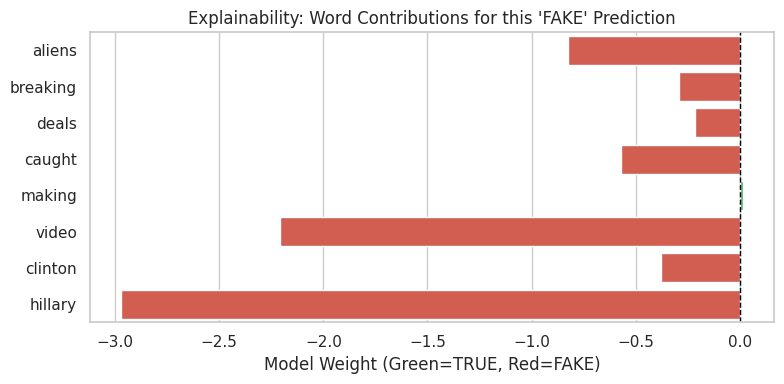


Text: 'The new healthcare bill was passed by the senate this morning....'
Prediction: FAKE (Confidence: 52.37%)


/tmp/ipykernel_3827/517941934.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights, y=words, palette=colors)


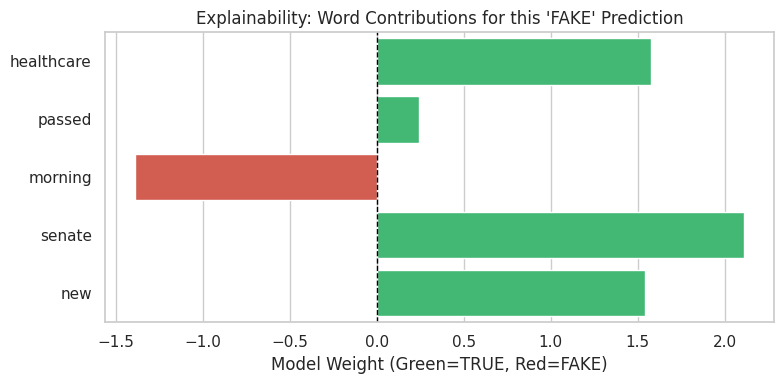


--- EXPERIMENT RUN COMPLETE ---


In [ ]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Set visualization theme
sns.set_theme(style="whitegrid")

print("--- STEP 1: DOWNLOADING & LOADING DATASET ---")
path = kagglehub.dataset_download("emineyetm/fake-news-detection-datasets")
print("Path to dataset files:", path)

try:
    data_dir = os.path.join(path, 'News _dataset')
    df_fake = pd.read_csv(os.path.join(data_dir, 'Fake.csv'))
    df_true = pd.read_csv(os.path.join(data_dir, 'True.csv'))

    df_fake['label'] = 0 # 0 for Fake
    df_true['label'] = 1 # 1 for True

    # Combine and sample to save memory/time
    df = pd.concat([df_fake, df_true], ignore_index=True).sample(frac=0.3, random_state=42)
    print(f"Dataset loaded successfully. Total samples used: {len(df)}")
except Exception as e:
    print("Error loading CSVs. Please check the file names in the directory.", e)

print("\n--- STEP 2: PREPROCESSING & DEBIASING ---")

def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    return text.lower()

biased_entities = ['reuters', 'trump', 'obama', 'hillary', 'clinton', 'washington', 'getty', 'images']

def clean_text_debiased(text):
    text = clean_text(text)
    for word in biased_entities:
        text = re.sub(rf"\b{word}\b", "", text)
    return text

df['text_clean'] = df['text'].apply(clean_text)
df['text_debiased'] = df['text'].apply(clean_text_debiased)
print("Text cleaning complete.")

print("\n--- STEP 3: MODEL TRAINING (Q1: PERFORMANCE COMPARISON) ---")
# Train Biased Model
vec_b = TfidfVectorizer(max_features=5000, stop_words='english')
X_b = vec_b.fit_transform(df['text_clean'])
y = df['label']

X_train_b, X_test_b, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)
model_biased = LogisticRegression(max_iter=1000)
model_biased.fit(X_train_b, y_train)
acc_b = accuracy_score(y_test, model_biased.predict(X_test_b))

# Train Debiased Model
vec_d = TfidfVectorizer(max_features=5000, stop_words='english')
X_d = vec_d.fit_transform(df['text_debiased'])

X_train_d, X_test_d, _, _ = train_test_split(X_d, y, test_size=0.2, random_state=42)
model_debiased = LogisticRegression(max_iter=1000)
model_debiased.fit(X_train_d, y_train)
acc_d = accuracy_score(y_test, model_debiased.predict(X_test_d))

print(f"Accuracy BEFORE removing identifiable/biased data: {acc_b:.4f}")
print(f"Accuracy AFTER removing identifiable/biased data:  {acc_d:.4f}")

# VISUALIZATION 1: Accuracy Comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=['Biased Model (Full Data)', 'Debiased Model (Filtered)'], y=[acc_b, acc_d], palette=['#e74c3c', '#2ecc71'])
plt.ylim(0.9, 1.0) # Zoom in to see the difference clearly
plt.title('Impact of Removing Identifiable Data on Accuracy', fontsize=14, pad=15)
plt.ylabel('Accuracy Score')
for i, v in enumerate([acc_b, acc_d]):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- STEP 4: BIAS IDENTIFICATION (Q2: MODEL BIAS) ---")
feature_names = vec_b.get_feature_names_out()
coefficients = model_biased.coef_[0]

top_fake_idx = np.argsort(coefficients)[:15]
top_true_idx = np.argsort(coefficients)[-15:]

top_fake_words = [feature_names[i] for i in top_fake_idx]
top_fake_weights = coefficients[top_fake_idx]

top_true_words = [feature_names[i] for i in top_true_idx]
top_true_weights = coefficients[top_true_idx]

# VISUALIZATION 2: Top Biased Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_fake_weights, y=top_fake_words, ax=axes[0], palette="Reds_r")
axes[0].set_title('Top Words Pushing Model Toward FAKE (-)', fontsize=14)
axes[0].set_xlabel('Coefficient Weight')

sns.barplot(x=top_true_weights, y=top_true_words, ax=axes[1], palette="Greens_d")
axes[1].set_title('Top Words Pushing Model Toward TRUE (+)', fontsize=14)
axes[1].set_xlabel('Coefficient Weight')

plt.tight_layout()
plt.show()

print("\n--- STEP 5: EXPLAINABILITY & PUBLIC DEPLOYMENT (Q3 & Q5) ---")
def explain_prediction_visual(text, model, vectorizer):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    label = "TRUE" if pred == 1 else "FAKE"
    confidence = max(prob) * 100

    print(f"\nText: '{text[:100]}...'")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)")

    # Get word contributions
    feature_array = np.array(vectorizer.get_feature_names_out())
    tfidf_sorting = np.argsort(vec.toarray()).flatten()[::-1]

    words = []
    weights = []

    count = 0
    for idx in tfidf_sorting:
        if vec.toarray()[0][idx] > 0 and count < 8: # Top 8 words in this text
            word = feature_array[idx]
            weight = model.coef_[0][idx]
            words.append(word)
            weights.append(weight)
            count += 1

    if words:
        plt.figure(figsize=(8, 4))
        # Color code: Green if positive weight (True), Red if negative weight (Fake)
        colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]
        sns.barplot(x=weights, y=words, palette=colors)
        plt.title(f"Explainability: Word Contributions for this '{label}' Prediction", fontsize=12)
        plt.xlabel("Model Weight (Green=TRUE, Red=FAKE)")
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
        plt.tight_layout()
        plt.show()

# Test samples
test_samples = [
    "Washington (Reuters) - The President signed a new executive order today.",
    "Breaking: Hillary Clinton caught on video making deals with aliens!",
    "The new healthcare bill was passed by the senate this morning."
]

for sample in test_samples:
    explain_prediction_visual(sample, model_biased, vec_b)

print("\n--- EXPERIMENT RUN COMPLETE ---")